# Class Notes: Decision Trees and Ensembles (19 June 2026)

Topics covered:
1. Decision tree and its flow
2. Decision tree for regression
3. Pure vs impure nodes
4. Recursive binary splitting (greedy approach)
5. Drawbacks and tree pruning (pre and post)
6. Classification trees: entropy, information gain, Gini impurity
7. Algorithms: ID3, C4.5, CART
8. Advantages and disadvantages
9. Cross validation: hold out, k fold, LOOCV
10. Parameters: criterion, splitter
11. Ensemble techniques: bagging and boosting (introduced here, boosting deep dive on 23 June)

---

In [1]:

# Setup for this notebook
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt


## 1. Decision Tree and Its Flow

Logistic regression drew one straight boundary. A decision tree takes a completely different approach: it asks a series of yes/no questions.

**A decision tree is a model that splits the data by asking one feature question at a time, branching down until it reaches a leaf that gives the prediction.**

Plainly: it is a flowchart the model builds automatically, where each internal node is a test on a feature and each leaf is an answer.

```
                [ Is income > 50k? ]
                  /            \
                yes             no
                /                \
     [ age > 30? ]            [ predict: decline ]
       /       \
     yes        no
     /           \
[ approve ]   [ decline ]
```

Vocabulary: the top node is the **root**, internal test nodes are **decision nodes**, and the final answer nodes are **leaves**. A path from root to leaf is one decision rule.

---

## 2. Decision Tree for Regression

Trees are not only for classes. For a numeric target the tree splits the same way, and each leaf predicts the **average of the training targets that landed in it**.

Plainly: instead of a smooth line, a regression tree carves the input space into boxes and predicts one flat value per box. This is why a regression tree's prediction looks like a staircase rather than a slope.

---

## 3. Pure vs Impure Nodes

The whole point of a split is to make the groups cleaner.

**A pure node contains samples of only one class. An impure node is a mix of classes.**

Plainly: pure is a leaf you can trust ("everyone here is class yes"), impure still needs splitting. Every splitting rule below is just a way to measure impurity so the tree can drive it down.

---

## 4. Recursive Binary Splitting (Greedy Approach)

**Recursive binary splitting is the process of repeatedly choosing the single best feature and threshold to split on, then repeating on each resulting branch.**

Plainly: at every node the tree tries every possible split, keeps the one that most reduces impurity, and then does the same thing again on the two children, over and over.

It is called **greedy** because at each step it grabs the best split available right now without looking ahead to whether a different split now would allow a better tree later. Greedy is fast and usually good, but it is not guaranteed to build the globally optimal tree.

---

## 5. Drawbacks and Tree Pruning

The main drawback: left unchecked, a tree keeps splitting until every leaf is pure, which means it memorizes the training data. That is textbook overfitting (high variance), the same disease from the bias variance notes.

**Pruning is cutting the tree back so it generalizes better instead of memorizing.**

Two timings:

- **Pre-pruning (early stopping)**: stop growing while building, using limits like max depth, minimum samples per leaf, or a minimum impurity decrease. Cheaper, but it might stop too early and miss a good split further down.
- **Post-pruning**: grow the full tree first, then snip back branches that do not improve validation performance. More expensive, but it sees the whole tree before deciding what to cut.

Plainly: pre-pruning refuses to grow past a limit, post-pruning grows fully then trims.

---

## 6. Classification Trees: measuring impurity

To pick splits, a classification tree needs a number for how messy a node is. Three measures.

### Entropy

**Entropy measures the disorder in a node, 0 for a pure node and 1 (for two balanced classes) for maximum mixing.**

```
Entropy = - sum over classes( p * log2(p) )
```

Plainly: if a node is all one class, entropy is 0 (no surprise), and if it is a 50/50 mix, entropy is 1 (maximum surprise).

Worked example, a node with 9 yes and 5 no:

```
Entropy(9 yes, 5 no) = -(9/14)log2(9/14) - (5/14)log2(5/14) = 0.9403
```

(Verified in Python.)

### Information Gain

**Information gain is how much the entropy drops after a split, weighted by the size of each child.**

```
Information Gain = Entropy(parent) - sum( (child_size / parent_size) * Entropy(child) )
```

Plainly: it measures how much cleaner the split made things. The tree picks the split with the highest information gain.

Worked example, splitting the (9,5) parent into child1 (6 yes, 2 no) and child2 (3 yes, 3 no):

```
Entropy(6,2) = 0.8113
Entropy(3,3) = 1.0000   (a perfect 50/50, max disorder)
Weighted child entropy = (8/14)(0.8113) + (6/14)(1.0000) = 0.8922
Information Gain = 0.9403 - 0.8922 = 0.0481
```

(Verified in Python.) A positive gain means the split helped, and the tree compares this number across every candidate split to choose the winner.

### Gini Impurity

**Gini impurity is the probability of misclassifying a random sample if you labeled it by the node's class distribution, 0 for pure and 0.5 (two classes) for a even mix.**

```
Gini = 1 - sum over classes( p^2 )
```

Worked examples:

```
Gini(9 yes, 5 no) = 1 - ((9/14)^2 + (5/14)^2) = 0.4592
Gini(6 yes, 2 no) = 0.3750
Gini(3 yes, 3 no) = 0.5000   (max impurity for two classes)
```

(Verified in Python.) Gini and entropy usually pick the same splits. Gini is slightly cheaper to compute (no logarithm), which is why it is the default in scikit-learn.

---

In [2]:
# entropy, information gain, and gini impurity by hand
def entropy(counts):
    total = sum(counts)
    ps = [c / total for c in counts if c > 0]
    return -sum(p * np.log2(p) for p in ps)

def gini(counts):
    total = sum(counts)
    return 1 - sum((c / total) ** 2 for c in counts)

parent = entropy([9, 5])
c1, c2 = entropy([6, 2]), entropy([3, 3])
weighted = (8 / 14) * c1 + (6 / 14) * c2
info_gain = parent - weighted

print(f"parent entropy (9 yes, 5 no) = {parent:.4f}")
print(f"child1 (6,2) = {c1:.4f}   child2 (3,3) = {c2:.4f}")
print(f"weighted child entropy       = {weighted:.4f}")
print(f"information gain             = {info_gain:.4f}")
print()
print(f"gini(9,5) = {gini([9,5]):.4f}   gini(6,2) = {gini([6,2]):.4f}   gini(3,3) = {gini([3,3]):.4f}")

parent entropy (9 yes, 5 no) = 0.9403
child1 (6,2) = 0.8113   child2 (3,3) = 1.0000
weighted child entropy       = 0.8922
information gain             = 0.0481

gini(9,5) = 0.4592   gini(6,2) = 0.3750   gini(3,3) = 0.5000


## 7. Different Algorithms for Decision Trees

| Algorithm | Split criterion | Notes |
|---|---|---|
| ID3 | information gain (entropy) | classification only, categorical features, multiway splits |
| C4.5 | gain ratio | successor to ID3, handles continuous features and missing values |
| CART | Gini (classification) or variance (regression) | binary splits only, does both classification and regression |

Plainly: CART is the one scikit-learn implements, which is why every tree you fit there is binary and uses Gini by default.

---

## 8. Advantages and Disadvantages of Decision Trees

Advantages: easy to read and explain (you can literally draw the rules), needs little data preprocessing (no scaling required, unlike logistic regression), handles both numeric and categorical features, and captures nonlinear patterns that a straight line cannot.

Disadvantages: a single tree overfits easily and is unstable (a small data change can reshape the whole tree), it is greedy so not globally optimal, and it can be biased toward features with many levels. Most of these are fixed by combining many trees, which is the ensemble section.

---

## 9. Cross Validation

We keep saying "check on validation data." Cross validation is the disciplined way to do that.

**Cross validation estimates how a model will perform on unseen data by training and testing on different splits of the data.**

- **Hold out method**: split once into train and test (say 80/20). Simple, but the estimate depends heavily on which rows happened to land in the test set.
- **k fold cross validation**: split into k equal folds, train on k minus 1 and test on the held out fold, rotate so every fold is the test set once, then average the k scores. More stable because every row gets used for testing exactly once. k = 5 or 10 is typical.
- **LOOCV (Leave One Out)**: k fold taken to the extreme where k equals the number of rows, so each test set is a single row. Almost unbiased but very expensive, since it trains the model n times.

```
5 fold cross validation:
fold:   [ 1 ][ 2 ][ 3 ][ 4 ][ 5 ]
run 1:  test  train train train train
run 2:  train test  train train train
...     (rotate the test fold through all 5, average the scores)
```

---

5-fold accuracies: [0.933 0.967 0.9   0.867 1.   ]
mean accuracy    : 0.933


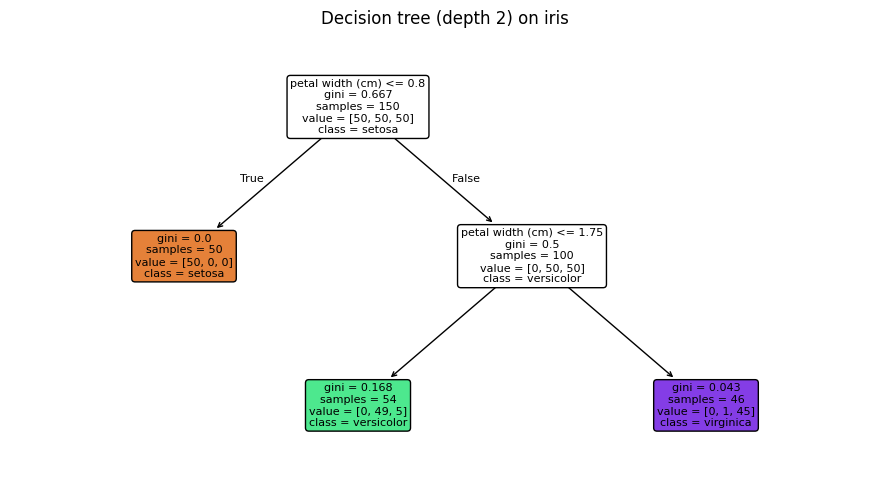

In [3]:
# fit a decision tree, score it with k-fold cross validation, and draw it
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score

iris = load_iris()
tree = DecisionTreeClassifier(max_depth=2, random_state=0)
scores = cross_val_score(tree, iris.data, iris.target, cv=5)   # 5-fold
print("5-fold accuracies:", np.round(scores, 3))
print(f"mean accuracy    : {scores.mean():.3f}")

tree.fit(iris.data, iris.target)
plt.figure(figsize=(9, 5))
plot_tree(tree, feature_names=iris.feature_names,
          class_names=iris.target_names, filled=True, rounded=True, fontsize=8)
plt.title("Decision tree (depth 2) on iris"); plt.tight_layout(); plt.show()

## 10. Parameters

Two of the first hyperparameters you tune on a tree:

- **criterion**: which impurity measure to split on, `gini` or `entropy` for classification. They usually behave similarly, so this is a minor knob.
- **splitter**: how the split point is chosen at each node. `best` evaluates all candidate splits and picks the top one (default), `random` picks the best among a random subset, which is faster and adds randomness that can reduce overfitting.

Other common ones (all pre-pruning): `max_depth`, `min_samples_split`, `min_samples_leaf`.

---

## 11. Ensemble Techniques

A single tree is unstable, so instead of trusting one, we combine many. That is the ensemble idea, and it fixes the biggest weakness of trees.

**An ensemble combines many models so that their combined prediction is better and more stable than any single model.**

There are two main families.

### Bagging (Bootstrap Aggregating)

**Bagging trains many trees in parallel, each on a random bootstrap sample of the data, then averages their predictions (or takes a majority vote).**

Plainly: build lots of independent trees on slightly different slices of the data and let them vote, which cancels out the wild swings of any single tree. This attacks variance. Random Forest is bagging plus one extra twist: each split only considers a random subset of features, which stops all the trees from looking alike.

```
Bagging (parallel):
   data --> [tree1]  \
   data --> [tree2]   >  average / vote --> prediction
   data --> [tree3]  /
   (trees are independent, built at the same time)
```

### Boosting

**Boosting trains trees one after another, where each new tree focuses on the mistakes the previous ones made, then combines them into a weighted sum.**

Plainly: build weak trees in sequence, and each one pays extra attention to the rows the earlier trees got wrong. This attacks bias, turning a bunch of weak learners into one strong learner.

```
Boosting (sequential):
   [tree1] -> look at errors -> [tree2] -> look at errors -> [tree3] -> ...
   (each tree corrects the one before it)
```

The weak learner is usually a very shallow tree (often a stump, depth 1), which is why boosting builds directly on today's tree material.

Summary of the two families: bagging reduces variance by averaging independent trees built in parallel, boosting reduces bias by stacking corrective trees in sequence. Both turn the fragile single tree from earlier today into something you can actually deploy.

### Where this goes next

Today introduces the two ensemble families at a high level. The boosting deep dive (why a shallow tree is the weak learner, AdaBoost, Gradient Boosting, and XGBoost, with worked examples and code) is the next session, in the 23 June notes.

In [4]:
# bagging in action: a single tree vs a random forest on the same data
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

X, y = load_breast_cancer(return_X_y=True)
single = cross_val_score(DecisionTreeClassifier(random_state=0), X, y, cv=5).mean()
forest = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=0), X, y, cv=5).mean()
print(f"single decision tree    5-fold accuracy = {single:.4f}")
print(f"random forest (bagging) 5-fold accuracy = {forest:.4f}")
print("\naveraging many trees (bagging) lifts accuracy over one tree by cutting variance")
print("the boosting deep dive (AdaBoost, gradient boosting, XGBoost) is in the 23 June notebook")

single decision tree    5-fold accuracy = 0.9174
random forest (bagging) 5-fold accuracy = 0.9631

averaging many trees (bagging) lifts accuracy over one tree by cutting variance
the boosting deep dive (AdaBoost, gradient boosting, XGBoost) is in the 23 June notebook
